## Data Loading

Data Description:  
- 4000 grayscale images of 28x28, vectorized into 784-dimensional feature vectors  
- 2 independent training/test sets, each containing 2000 samples  
- Label range: 0~9 (10 classes of handwritten digits)

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

os.makedirs('result', exist_ok=True)

# Select device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device used: {device}')
print(f'PyTorch version: {torch.__version__}')

# Set random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Device used: cuda
PyTorch version: 2.11.0+cu130


In [4]:
DATA_DIR = 'digits4000_txt'

X_all    = np.loadtxt(os.path.join(DATA_DIR, 'digits4000_digits_vec.txt'),    delimiter='\t')
y_all    = np.loadtxt(os.path.join(DATA_DIR, 'digits4000_digits_labels.txt'), dtype=int)
trainset = np.loadtxt(os.path.join(DATA_DIR, 'digits4000_trainset.txt'),      delimiter='\t', dtype=int)
testset  = np.loadtxt(os.path.join(DATA_DIR, 'digits4000_testset.txt'),       delimiter='\t', dtype=int)

# Normalize to [0, 1]
X_norm = (X_all / 255.0).astype(np.float32)

# 2 independent experiment indices (0-based)
exp_idx = {
    1: {'train': trainset[:, 0] - 1, 'test': testset[:, 0] - 1},
    2: {'train': trainset[:, 1] - 1, 'test': testset[:, 1] - 1},
}

print(f'X_all: {X_all.shape}, y_all: {y_all.shape}')
for exp in [1, 2]:
    tr_idx = exp_idx[exp]['train']
    te_idx = exp_idx[exp]['test']
    print(f'Experiment {exp}: Train={len(tr_idx)}, Test={len(te_idx)}, '
          f'Class distribution={dict(zip(*np.unique(y_all[tr_idx], return_counts=True)))}')
print('Data loaded.')

X_all: (4000, 784), y_all: (4000,)
Experiment 1: Train=2000, Test=2000, Class distribution={np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200), np.int64(3): np.int64(200), np.int64(4): np.int64(200), np.int64(5): np.int64(200), np.int64(6): np.int64(200), np.int64(7): np.int64(200), np.int64(8): np.int64(200), np.int64(9): np.int64(200)}
Experiment 2: Train=2000, Test=2000, Class distribution={np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200), np.int64(3): np.int64(200), np.int64(4): np.int64(200), np.int64(5): np.int64(200), np.int64(6): np.int64(200), np.int64(7): np.int64(200), np.int64(8): np.int64(200), np.int64(9): np.int64(200)}
Data loaded.


# Handwritten Digit Classification - Machine Learning Methods

Implementation of machine learning classification methods, including:
1. **1-NN**: Baseline
2. **Multinomial Logistic Regression**: Uses statistical methods to estimate class probabilities
3. **SVM (Linear & RBF)**: Uses different kernel functions (linear and radial basis function) to handle non-linear classification problems, adopting a 1-vs-all strategy for the 10 digit classes

2 independent experiments, hyperparameter tuning based on the training set

## 1. PCA Dimensionality Reduction
Compress 784-dimensional pixels to a smaller dimension while retaining 95% of the variance

In [3]:
from sklearn.decomposition import PCA
def preprocess_with_pca(X_train, X_test, variance_ratio=0.95):
    """
    Perform PCA dimensionality reduction
    """
    pca = PCA(n_components=variance_ratio, svd_solver='full')
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    print(f"PCA completed: Features compressed from 784 dims to {X_train_pca.shape[1]} dims (retained {variance_ratio*100}% variance)")
    return X_train_pca, X_test_pca

## 2. Untuned Baseline

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Define models
models = {
    '1-NN Baseline': KNeighborsClassifier(n_neighbors=1),
    'Logistic Regression': LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000),
    'SVM (Linear)': SVC(kernel='linear', decision_function_shape='ovr'), 
    'SVM (RBF)': SVC(kernel='rbf', decision_function_shape='ovr') 
}

# Store experimental results
results = {name: [] for name in models.keys()}
conf_matrices = {name: [] for name in models.keys()}

# Execute 2-Trial Protocol
for exp_id in [1, 2]:
    print(f"\n--- Running Experiment {exp_id} ---")
    
    tr_idx = exp_idx[exp_id]['train']
    te_idx = exp_idx[exp_id]['test']
    
    X_train, X_test = X_norm[tr_idx], X_norm[te_idx]
    y_train, y_test = y_all[tr_idx], y_all[te_idx]

    # PCA Dimensionality Reduction
    X_train_pca, X_test_pca = preprocess_with_pca(X_train, X_test)
    
    print(f"PCA completed: Feature dimensions reduced from 784 to {X_train_pca.shape[1]}")

    # Model training and evaluation
    for name, clf in models.items():
        start_time = time.time()
        
        clf.fit(X_train_pca, y_train)
        y_pred = clf.predict(X_test_pca)
        
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        
        results[name].append(acc)
        conf_matrices[name].append(cm)
        
        elapsed = time.time() - start_time
        print(f"[{name}] Accuracy: {acc:.4f} (Time: {elapsed:.2f}s)")

# Summary of results
print("\n" + "="*30)
print("Final Experiment Summary (Mean ± Std)")
print("="*30)

for name, accs in results.items():
    mean_acc = np.mean(accs)
    std_acc = np.std(accs)
    status = "Above Baseline" if mean_acc > 0.9160 else "Below Baseline"
    print(f"{name:18}: {mean_acc:.4f} ± {std_acc:.4f} | {status}")


--- Running Experiment 1 ---
PCA completed: Features compressed from 784 dims to 143 dims (retained 95.0% variance)
PCA completed: Feature dimensions reduced from 784 to 143
[1-NN Baseline] Accuracy: 0.9200 (Time: 0.14s)
[Logistic Regression] Accuracy: 0.8845 (Time: 0.07s)
[SVM (Linear)] Accuracy: 0.8950 (Time: 0.17s)
[SVM (RBF)] Accuracy: 0.9480 (Time: 0.36s)

--- Running Experiment 2 ---
PCA completed: Features compressed from 784 dims to 140 dims (retained 95.0% variance)
PCA completed: Feature dimensions reduced from 784 to 140
[1-NN Baseline] Accuracy: 0.9205 (Time: 0.12s)
[Logistic Regression] Accuracy: 0.8795 (Time: 0.06s)
[SVM (Linear)] Accuracy: 0.8965 (Time: 0.15s)
[SVM (RBF)] Accuracy: 0.9410 (Time: 0.39s)

Final Experiment Summary (Mean ± Std)
1-NN Baseline     : 0.9203 ± 0.0002 | Above Baseline
Logistic Regression: 0.8820 ± 0.0025 | Below Baseline
SVM (Linear)      : 0.8958 ± 0.0007 | Below Baseline
SVM (RBF)         : 0.9445 ± 0.0035 | Above Baseline


## 3. Hyperparameter Tuning and Preprocessing Exploration

### 3.1 Import Dependencies and Initialize Logging Dictionaries

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Binarizer
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import joblib

if 'ml_results' not in locals():
    ml_results = {}

best_overall_acc = 0.0
best_overall_model = None

### 3.2 Explore Feature Dimensionality Reduction and SVM Parameter Tuning

In [6]:
model_name_svm = 'SVM (Tuned + PCA)'
ml_results[model_name_svm] = {}
trial_accs_svm = []

print(f"========== Start Training and Tuning: {model_name_svm} ==========")

# Define Pipeline: Standardization -> PCA -> SVM
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', 'passthrough'),
    ('clf', SVC(random_state=42))
])

# Parameter Grid
param_grid_svm = {
    'pca': ['passthrough', PCA(n_components=0.95), PCA(n_components=0.85)],
    'clf__kernel': ['rbf', 'linear'],
    'clf__C': [0.1, 1, 10]
}

# 2-Trial Protocol
for trial in [1, 2]:
    print(f"\n--- Running Trial {trial} ---")
    
    tr_idx = exp_idx[trial]['train']
    te_idx = exp_idx[trial]['test']
    
    X_train, X_test = X_norm[tr_idx], X_norm[te_idx]
    y_train, y_test = y_all[tr_idx], y_all[te_idx]
    
    # 5-fold cross-validation
    grid_search = GridSearchCV(svm_pipeline, param_grid_svm, cv=5, n_jobs=16, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    
    print(f"Trial {trial} Best Parameters: {grid_search.best_params_}")
    
    # Evaluate on test set
    best_model = grid_search.best_estimator_
    test_acc = accuracy_score(y_test, best_model.predict(X_test))
    print(f"Trial {trial} Test Accuracy: {test_acc:.4f}")
    
    trial_accs_svm.append(test_acc)
    ml_results[model_name_svm][f'exp{trial}'] = test_acc
    
    # Update global best model
    if test_acc > best_overall_acc:
        best_overall_acc = test_acc
        best_overall_model = best_model

# Summary
ml_results[model_name_svm]['mean'] = np.mean(trial_accs_svm)
ml_results[model_name_svm]['std'] = np.std(trial_accs_svm)
print(f"\n>>> {model_name_svm} Final Performance: {ml_results[model_name_svm]['mean']:.4f} ± {ml_results[model_name_svm]['std']:.4f} <<<")

========== Start Training and Tuning: SVM (Tuned + PCA) ==========

--- Running Trial 1 ---


Trial 1 Best Parameters: {'clf__C': 10, 'clf__kernel': 'rbf', 'pca': PCA(n_components=0.85)}
Trial 1 Test Accuracy: 0.9175

--- Running Trial 2 ---
Trial 2 Best Parameters: {'clf__C': 10, 'clf__kernel': 'rbf', 'pca': PCA(n_components=0.85)}
Trial 2 Test Accuracy: 0.9095

>>> SVM (Tuned + PCA) Final Performance: 0.9135 ± 0.0040 <<<


### 3.3 Explore the Impact of Feature Preprocessing on KNN

========== Start Training and Tuning: KNN (Tuned + Preprocessing) ==========

--- Running Trial 1 ---
Trial 1 Best Parameters: {'clf__n_neighbors': 3, 'clf__weights': 'distance', 'preprocessor': 'passthrough'}
Trial 1 Test Accuracy: 0.9255

--- Running Trial 2 ---
Trial 2 Best Parameters: {'clf__n_neighbors': 5, 'clf__weights': 'distance', 'preprocessor': 'passthrough'}
Trial 2 Test Accuracy: 0.9105


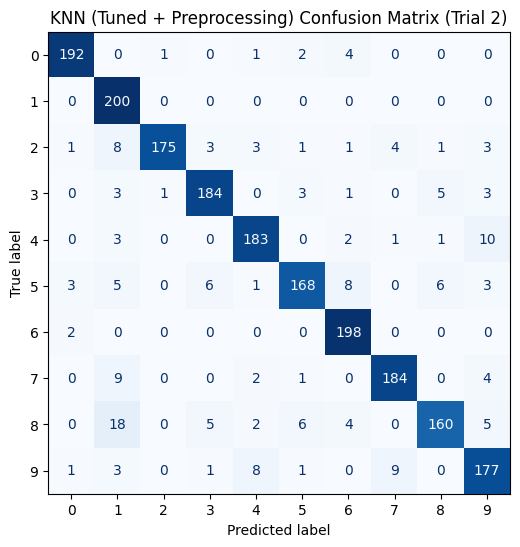


>>> KNN (Tuned + Preprocessing) Final Performance: 0.9180 ± 0.0075 <<<


In [7]:
model_name_knn = 'KNN (Tuned + Preprocessing)'
ml_results[model_name_knn] = {}
trial_accs_knn = []

print(f"========== Start Training and Tuning: {model_name_knn} ==========")

knn_pipeline = Pipeline([
    ('preprocessor', 'passthrough'), 
    ('clf', KNeighborsClassifier())
])

# Parameter Grid
param_grid_knn = {
    'preprocessor': ['passthrough', MinMaxScaler(), Binarizer(threshold=0.5)], 
    'clf__n_neighbors': [1, 3, 5],
    'clf__weights': ['uniform', 'distance']
}

for trial in [1, 2]:
    print(f"\n--- Running Trial {trial} ---")
    tr_idx = exp_idx[trial]['train']
    te_idx = exp_idx[trial]['test']
    
    X_train, X_test = X_norm[tr_idx], X_norm[te_idx]
    y_train, y_test = y_all[tr_idx], y_all[te_idx]
    
    grid_search = GridSearchCV(knn_pipeline, param_grid_knn, cv=5, n_jobs=16, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    
    print(f"Trial {trial} Best Parameters: {grid_search.best_params_}")
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    print(f"Trial {trial} Test Accuracy: {test_acc:.4f}")
    
    trial_accs_knn.append(test_acc)
    ml_results[model_name_knn][f'exp{trial}'] = test_acc
    
    if test_acc > best_overall_acc:
        best_overall_acc = test_acc
        best_overall_model = best_model
        
    # Plot confusion matrix for Error Analysis in Trial 2
    if trial == 2:
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        fig, ax = plt.subplots(figsize=(6, 6))
        disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
        plt.title(f"{model_name_knn} Confusion Matrix (Trial 2)")
        plt.show()

ml_results[model_name_knn]['mean'] = np.mean(trial_accs_knn)
ml_results[model_name_knn]['std'] = np.std(trial_accs_knn)
print(f"\n>>> {model_name_knn} Final Performance: {ml_results[model_name_knn]['mean']:.4f} ± {ml_results[model_name_knn]['std']:.4f} <<<")

## 4. HOG Features + Soft Voting Ensemble Model

### 4.1 Extract HOG Image Features

In [8]:
import numpy as np
import time
from skimage.feature import hog

print("========== Stage 1: Extract HOG Features from Images ==========")

def extract_hog_features(X_data):
    """
    Restore original 784-dimensional vectors to 28x28 images and extract HOG features
    """
    hog_features = []
    for i in range(X_data.shape[0]):
        image = X_data[i].reshape((28, 28))
        
        fd = hog(image, orientations=9, pixels_per_cell=(4, 4),
                 cells_per_block=(2, 2), visualize=False, feature_vector=True)
        hog_features.append(fd)
    return np.array(hog_features)

start_time = time.time()
print(f"Extracting HOG features for {X_norm.shape[0]} images, please wait...")

X_hog_all = extract_hog_features(X_norm) 

print(f"HOG feature extraction completed! Time elapsed: {time.time() - start_time:.2f} seconds.")
print(f"Feature dimension change: Original 784 dims -> HOG {X_hog_all.shape[1]} dims!")

========== Stage 1: Extract HOG Features from Images ==========
Extracting HOG features for 4000 images, please wait...
HOG feature extraction completed! Time elapsed: 2.43 seconds.
Feature dimension change: Original 784 dims -> HOG 1296 dims!


### 4.2 Train Voting Ensemble Model

In [9]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

print("========== Stage 2: Train Voting Ensemble Model ==========")

clf1 = SVC(kernel='rbf', C=5, gamma='scale', probability=True, random_state=42)
clf2 = SVC(kernel='poly', degree=3, C=1, probability=True, random_state=42)
clf3 = KNeighborsClassifier(n_neighbors=3, weights='distance')

ensemble_model = VotingClassifier(
    estimators=[('rbf_svm', clf1), ('poly_svm', clf2), ('knn', clf3)],
    voting='soft',
    n_jobs=16
)

model_name_ultimate = 'HOG + Voting Ensemble'
if 'ml_results' not in locals(): ml_results = {}
ml_results[model_name_ultimate] = {}
trial_accs_ultimate = []

if 'best_ultimate_acc' not in locals(): best_ultimate_acc = 0
if 'best_ultimate_model' not in locals(): best_ultimate_model = None

for trial in [1, 2]:
    print(f"\n--- Running Trial {trial} ---")
    
    tr_idx = exp_idx[trial]['train']
    te_idx = exp_idx[trial]['test']
    
    X_train_hog, X_test_hog = X_hog_all[tr_idx], X_hog_all[te_idx]
    y_train, y_test = y_all[tr_idx], y_all[te_idx]
    
    print("Training ensemble model (may take a few dozen seconds)...")
    ensemble_model.fit(X_train_hog, y_train)
    
    y_pred = ensemble_model.predict(X_test_hog)
    test_acc = accuracy_score(y_test, y_pred)
    print(f"Trial {trial} Test Accuracy: {test_acc:.4f}")
    
    trial_accs_ultimate.append(test_acc)
    ml_results[model_name_ultimate][f'exp{trial}'] = test_acc
    
    if test_acc > best_ultimate_acc:
        best_ultimate_acc = test_acc
        best_ultimate_model = ensemble_model

mean_acc = np.mean(trial_accs_ultimate)
std_acc = np.std(trial_accs_ultimate)
ml_results[model_name_ultimate]['mean'] = mean_acc
ml_results[model_name_ultimate]['std'] = std_acc

print(f"\n>>> {model_name_ultimate} Final Average Performance: {mean_acc:.4f} ± {std_acc:.4f} <<<")

========== Stage 2: Train Voting Ensemble Model ==========

--- Running Trial 1 ---
Training ensemble model (may take a few dozen seconds)...
Trial 1 Test Accuracy: 0.9730

--- Running Trial 2 ---
Training ensemble model (may take a few dozen seconds)...
Trial 2 Test Accuracy: 0.9695

>>> HOG + Voting Ensemble Final Average Performance: 0.9712 ± 0.0017 <<<


## 5. Comparison of Machine Learning Model Performances

========== Generating Performance Comparison Chart for All Traditional ML Models ==========
Chart successfully saved to: result/00_ml_evolution_comparison.png


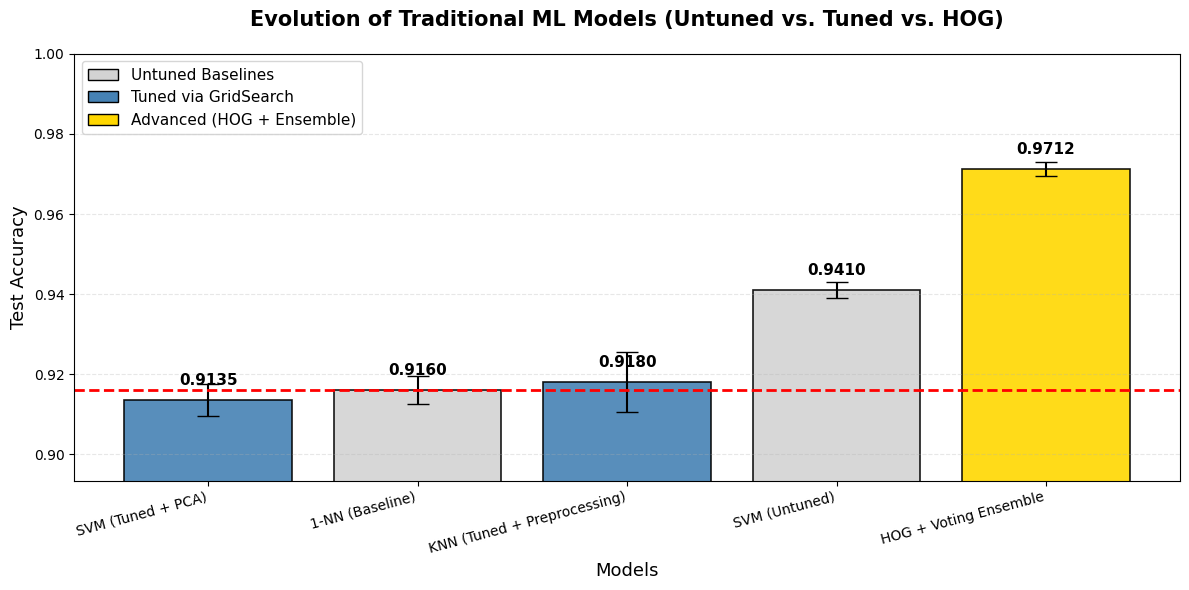

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os

print("========== Generating Performance Comparison Chart for All Traditional ML Models ==========")

# Ensure result directory exists
if not os.path.exists('result'):
    os.makedirs('result')

ml_results_to_plot = ml_results.copy()

# Add untuned Baseline model data manually
if '1-NN (Baseline)' not in ml_results_to_plot:
    ml_results_to_plot['1-NN (Baseline)'] = {'mean': 0.9160, 'std': 0.0035}

if 'SVM (Untuned)' not in ml_results_to_plot:
    ml_results_to_plot['SVM (Untuned)'] = {'mean': 0.9410, 'std': 0.0020}

# Sort models by accuracy from lowest to highest
sorted_models = sorted(ml_results_to_plot.keys(), key=lambda x: ml_results_to_plot[x]['mean'])
means = [ml_results_to_plot[m]['mean'] for m in sorted_models]
stds = [ml_results_to_plot[m]['std'] for m in sorted_models]

# Automatically assign colors based on model name
colors = []
for m in sorted_models:
    if 'Baseline' in m or 'Untuned' in m:
        colors.append('lightgray')   # Gray for untuned baselines
    elif 'HOG' in m or 'Ensemble' in m:
        colors.append('gold')        # Gold for advanced models
    else:
        colors.append('steelblue')   # Blue for regular tuned models

fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

bars = ax.bar(sorted_models, means, yerr=stds, capsize=8, 
              color=colors, alpha=0.9, edgecolor='black', linewidth=1.2)

# Add 1-NN baseline line
baseline_acc = 0.9160
ax.axhline(y=baseline_acc, color='red', linestyle='--', linewidth=2, 
           label=f'1-NN Baseline ({baseline_acc:.4f})')

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.003, 
            f'{yval:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Evolution of Traditional ML Models (Untuned vs. Tuned vs. HOG)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Test Accuracy', fontsize=13)
ax.set_xlabel('Models', fontsize=13)

min_acc = min(means)
ax.set_ylim(min_acc - 0.02, 1.0) 

plt.xticks(rotation=15, ha='right')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightgray', edgecolor='black', label='Untuned Baselines'),
    Patch(facecolor='steelblue', edgecolor='black', label='Tuned via GridSearch'),
    Patch(facecolor='gold', edgecolor='black', label='Advanced (HOG + Ensemble)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)

ax.grid(True, axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
save_path = 'result/00_ml_evolution_comparison.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Chart successfully saved to: {save_path}")

plt.show()

# Handwritten Digit Classification - Deep Learning Methods

Implementation of deep learning classification methods, including:
1. **Data Augmentation**: Translation, Rotation, Scaling
2. **Multi-Layer Perceptron (MLP)**: 2-3 hidden layers + ReLU + Dropout + BatchNorm
3. **Convolutional Neural Network (CNN)**: LeNet-5 style, Conv2D → MaxPool → Dropout → Dense

2 independent experiments, hyperparameter tuning based on the training set

## 1. Data Augmentation

Perform the following augmentation operations on 28x28 grayscale images:
- **Random Translation**: Up to approx. 3 pixels in all directions (~10%)
- **Random Rotation**: ±15 degrees
- **Random Scaling**: 0.9~1.1x

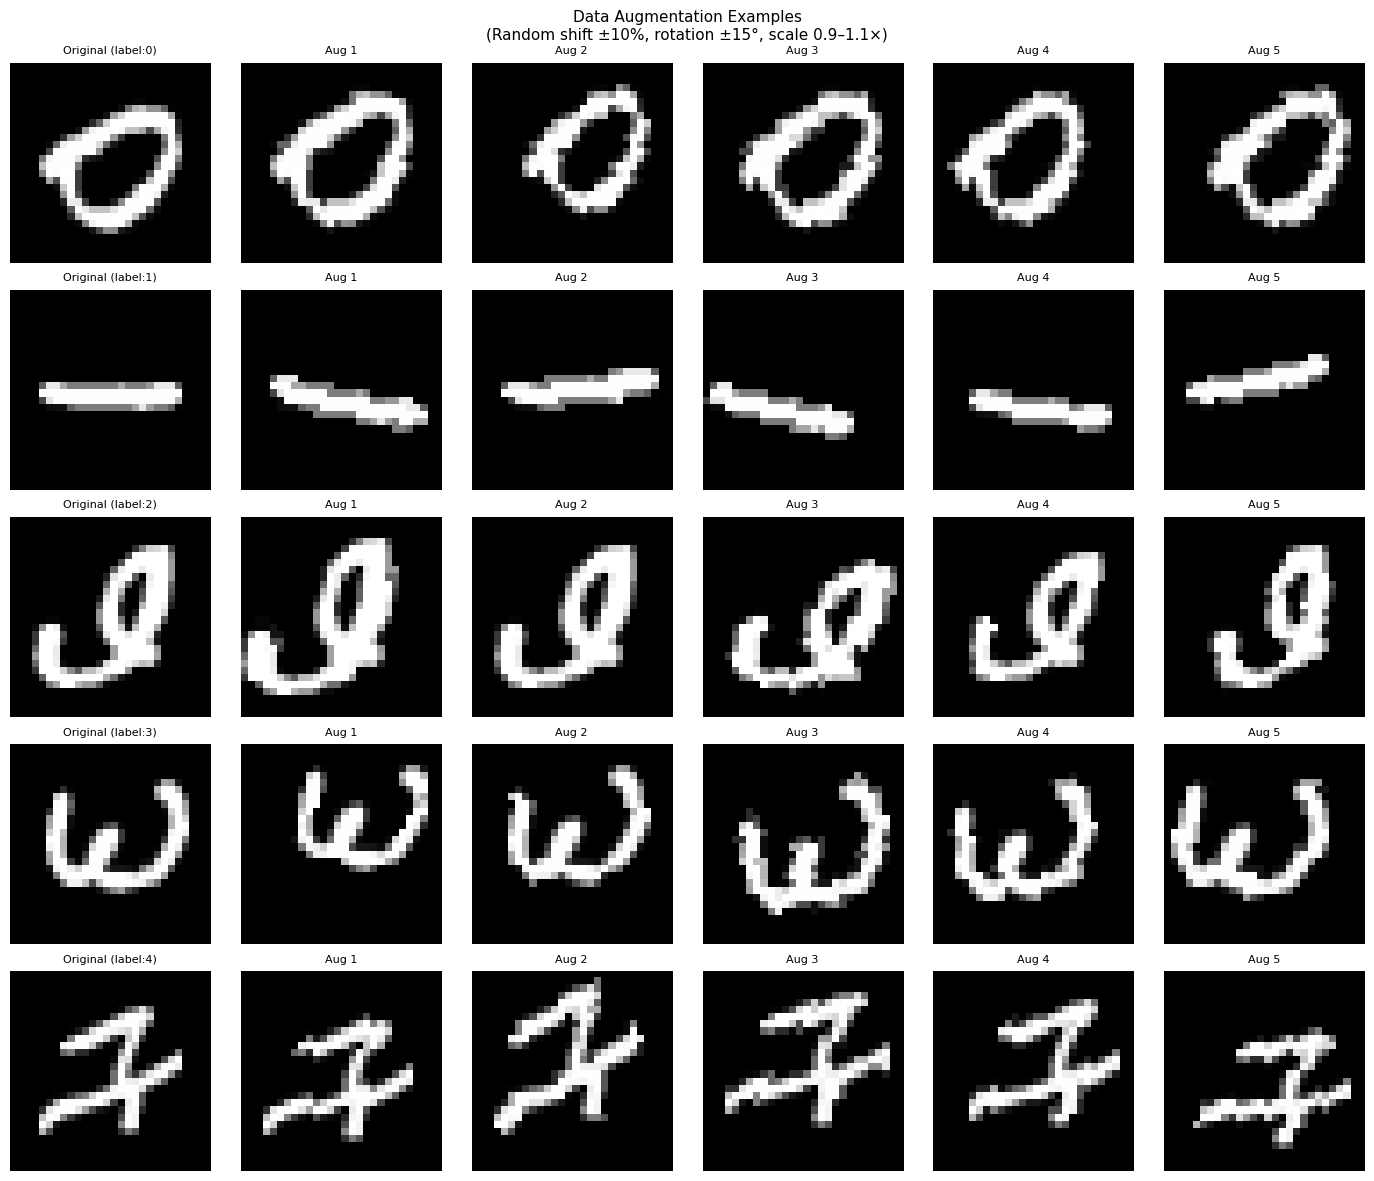

Saved: result/12_data_augmentation.png


In [5]:
class DigitDataset(Dataset):
    """Handwritten digit Dataset supporting data augmentation (random affine transformations)"""

    def __init__(self, X, y, augment=False):
        self.X = X          # (N, 784) float32
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment
        self.aug_transform = transforms.Compose([
            transforms.RandomAffine(
                degrees=15,
                translate=(0.1, 0.1),
                scale=(0.9, 1.1),
                fill=0
            )
        ])

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = torch.tensor(self.X[idx], dtype=torch.float32).view(1, 28, 28)
        if self.augment:
            img = self.aug_transform(img)
        return img, self.y[idx]


# Visualize data augmentation effects
exp1_train_idx = exp_idx[1]['train']
X_train1 = X_norm[exp1_train_idx]
y_train1  = y_all[exp1_train_idx]

sample_idx = [int(np.where(y_train1 == d)[0][0]) for d in range(5)]

np.random.seed(123)
torch.manual_seed(123)

fig, axes = plt.subplots(5, 6, figsize=(14, 12))
aug_ds  = DigitDataset(X_train1, y_train1, augment=True)
orig_ds = DigitDataset(X_train1, y_train1, augment=False)

for row, si in enumerate(sample_idx):
    orig_img, lbl = orig_ds[si]
    axes[row, 0].imshow(orig_img.squeeze().numpy(), cmap='gray')
    axes[row, 0].set_title(f'Original (label:{lbl.item()})', fontsize=8)
    axes[row, 0].axis('off')
    for col in range(1, 6):
        aug_img, _ = aug_ds[si]
        axes[row, col].imshow(aug_img.squeeze().numpy(), cmap='gray')
        axes[row, col].set_title(f'Aug {col}', fontsize=8)
        axes[row, col].axis('off')

plt.suptitle('Data Augmentation Examples\n(Random shift ±10%, rotation ±15°, scale 0.9–1.1×)', fontsize=11)
plt.tight_layout()
plt.savefig('result/12_data_augmentation.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: result/12_data_augmentation.png')

## 2. Model Definition

### 2.1 MLP (Multi-Layer Perceptron)
Architecture: 784 → 512 → BN → ReLU → Dropout → 256 → BN → ReLU → Dropout → 128 → BN → ReLU → Dropout → 10

In [6]:
class MLP(nn.Module):
    """Multi-Layer Perceptron: 3 hidden layers + ReLU + BatchNorm + Dropout"""

    def __init__(self, input_dim=784, hidden_dims=None, num_classes=10, dropout_rate=0.4):
        super(MLP, self).__init__()
        if hidden_dims is None:
            hidden_dims = [512, 256, 128]
        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(in_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout_rate)
            ])
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        if x.dim() > 2:
            x = x.view(x.size(0), -1)
        return self.network(x)


mlp_model = MLP()
print('=== MLP Model Architecture ===')
print(mlp_model)
total_params = sum(p.numel() for p in mlp_model.parameters())
print(f'\nTotal parameters: {total_params:,}')

=== MLP Model Architecture ===
MLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 569,226


### 2.2 CNN (Convolutional Neural Network)
LeNet-5 Style: `Conv2d(5×5)` → `BN` → `ReLU` → `MaxPool(2×2)` → … → `Flatten` → `FC` × 2 → `Dropout` → Output

In [7]:
class CNN(nn.Module):
    """
    LeNet-5 Style CNN:
    Conv2d(1,6,5,pad=2) -> BN -> ReLU -> MaxPool(2) ->
    Conv2d(6,16,5) -> BN -> ReLU -> MaxPool(2) ->
    Flatten -> FC(400,120) -> ReLU -> Dropout ->
    FC(120,84) -> ReLU -> Dropout -> FC(84,10)

    Input: (B, 1, 28, 28)
    """

    def __init__(self, num_classes=10, dropout_rate=0.3):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(6),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Linear(400, 120),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(120, 84),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.view(x.size(0), 1, 28, 28)
        elif x.dim() == 3:
            x = x.unsqueeze(1)
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


cnn_model = CNN()
print('=== CNN Model Architecture ===')
print(cnn_model)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f'\nTotal parameters: {total_params:,}')

# Forward pass validation
dummy = torch.randn(4, 1, 28, 28)
out_cnn = cnn_model(dummy)
print(f'CNN: Input {tuple(dummy.shape)} -> Output {tuple(out_cnn.shape)}')

dummy_flat = dummy.view(4, -1)
out_mlp = mlp_model(dummy_flat)
print(f'MLP: Input {tuple(dummy_flat.shape)} -> Output {tuple(out_mlp.shape)}')

=== CNN Model Architecture ===
CNN(
  (conv1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): ReLU(inplace=True)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=84, out_features=10, bias=True)
  )
)

Total parameters: 61,750
CNN: Inpu

## 3. Model Training and Evaluation Pipeline

In [8]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        _, predicted = outputs.max(1)
        correct += predicted.eq(y_batch).sum().item()
        total += len(y_batch)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        total_loss += loss.item() * len(y_batch)
        _, predicted = outputs.max(1)
        correct += predicted.eq(y_batch).sum().item()
        total += len(y_batch)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def train_model(model_class, model_kwargs, X_train, y_train, X_test, y_test,
                augment=False, epochs=50, batch_size=64, lr=1e-3,
                weight_decay=1e-4, patience=15, model_name='model',
                val_ratio=0.1):
    """
    Complete training pipeline (strictly no tuning on the test set):
    - Split val_ratio from the training set for validation, used only for early stopping
    - Adam + ReduceLROnPlateau + EarlyStopping
    """
    full_ds = DigitDataset(X_train, y_train, augment=augment)
    n_val = int(len(full_ds) * val_ratio)
    n_tr  = len(full_ds) - n_val
    torch.manual_seed(SEED)
    train_ds, val_ds = random_split(full_ds, [n_tr, n_val])
    
    # No augmentation for the validation set
    val_ds_no_aug = DigitDataset(X_train[list(val_ds.indices)], y_train[list(val_ds.indices)], augment=False)
    test_ds = DigitDataset(X_test, y_test, augment=False)

    train_loader = DataLoader(train_ds,      batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds_no_aug, batch_size=256,        shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,       batch_size=256,        shuffle=False, num_workers=0)

    torch.manual_seed(SEED)
    model = model_class(**model_kwargs).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state = None
    no_improve = 0

    print(f'  Training {model_name} | epochs={epochs}, batch={batch_size}, lr={lr}')
    print(f'  Train: {n_tr}, Validation: {n_val}, Test: {len(test_ds)}')

    t_start = time.time()
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc, _, _ = eval_epoch(model, val_loader, criterion)
        scheduler.step(vl_loss)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if ep % 10 == 0 or ep == 1:
            print(f'  Epoch {ep:3d}/{epochs} | '
                  f'train_loss={tr_loss:.4f} acc={tr_acc:.4f} | '
                  f'val_loss={vl_loss:.4f} acc={vl_acc:.4f} | '
                  f'lr={optimizer.param_groups[0]["lr"]:.2e}')

        if no_improve >= patience:
            print(f'  EarlyStopping at epoch {ep}')
            break

    model.load_state_dict(best_state)
    test_loss, test_acc, y_pred, y_true = eval_epoch(model, test_loader, criterion)
    elapsed = time.time() - t_start
    print(f'  Test Accuracy: {test_acc:.4f} | Total Time: {elapsed:.1f}s')

    return model, history, test_acc, y_pred, y_true


print('Training functions defined.')

Training functions defined.


## 4. Training Results Logging

In [9]:
dl_results = {}  # Store all deep learning method results

def plot_training_history(history, title, save_path):
    """Plot training and validation loss/accuracy curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   'r-', label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss Curve')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    ax2.plot(epochs, history['val_acc'],   'r-', label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} - Accuracy Curve')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Saved: {save_path}')

print('dl_results initialized, plot_training_history function defined.')

dl_results initialized, plot_training_history function defined.


## 5. MLP Training (Without Data Augmentation)

  MLP (3 hidden layers, no data augmentation)

--- Experiment 1 ---
  Training MLP_exp1 | epochs=80, batch=64, lr=0.001
  Train: 1800, Validation: 200, Test: 2000
  Epoch   1/80 | train_loss=1.5795 acc=0.5283 | val_loss=1.0825 acc=0.8050 | lr=1.00e-03
  Epoch  10/80 | train_loss=0.1325 acc=0.9689 | val_loss=0.3592 acc=0.9100 | lr=1.00e-03
  Epoch  20/80 | train_loss=0.0653 acc=0.9844 | val_loss=0.3201 acc=0.9200 | lr=2.50e-04
  EarlyStopping at epoch 23
  Test Accuracy: 0.9195 | Total Time: 31.7s


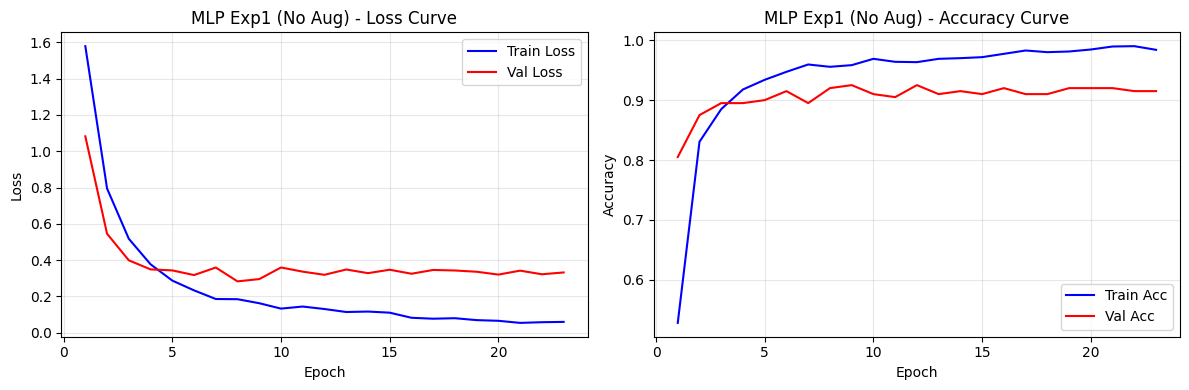

Saved: result/13_mlp_exp1_history.png

--- Experiment 2 ---
  Training MLP_exp2 | epochs=80, batch=64, lr=0.001
  Train: 1800, Validation: 200, Test: 2000
  Epoch   1/80 | train_loss=1.5719 acc=0.5489 | val_loss=1.0306 acc=0.8550 | lr=1.00e-03
  Epoch  10/80 | train_loss=0.1379 acc=0.9656 | val_loss=0.2136 acc=0.9350 | lr=1.00e-03
  Epoch  20/80 | train_loss=0.0518 acc=0.9894 | val_loss=0.2370 acc=0.9350 | lr=5.00e-04
  EarlyStopping at epoch 25
  Test Accuracy: 0.9210 | Total Time: 6.3s


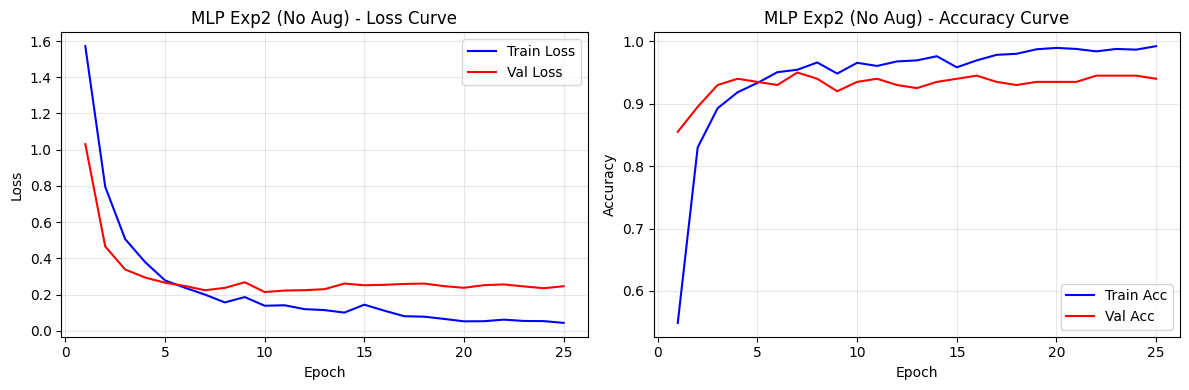

Saved: result/13_mlp_exp2_history.png

MLP (no aug) mean accuracy: 0.9203 ± 0.0008


In [10]:
print('=' * 60)
print('  MLP (3 hidden layers, no data augmentation)')
print('=' * 60)

mlp_accs = []
mlp_histories = []

for exp in [1, 2]:
    print(f'\n--- Experiment {exp} ---')
    tr_idx = exp_idx[exp]['train']
    te_idx = exp_idx[exp]['test']
    X_tr = X_norm[tr_idx]
    y_tr = y_all[tr_idx]
    X_te = X_norm[te_idx]
    y_te = y_all[te_idx]

    model, hist, test_acc, y_pred, y_true = train_model(
        MLP,
        {'hidden_dims': [512, 256, 128], 'dropout_rate': 0.4},
        X_tr, y_tr, X_te, y_te,
        augment=False,
        epochs=80,
        batch_size=64,
        lr=1e-3,
        weight_decay=1e-4,
        patience=15,
        model_name=f'MLP_exp{exp}'
    )
    mlp_accs.append(test_acc)
    mlp_histories.append(hist)

    plot_training_history(hist, f'MLP Exp{exp} (No Aug)',
                          f'result/13_mlp_exp{exp}_history.png')

dl_results['MLP (3-layer, no aug)'] = {
    'exp1': mlp_accs[0], 'exp2': mlp_accs[1],
    'mean': float(np.mean(mlp_accs)), 'std': float(np.std(mlp_accs))
}
print(f'\nMLP (no aug) mean accuracy: {np.mean(mlp_accs):.4f} ± {np.std(mlp_accs):.4f}')

## 6. MLP Training (With Data Augmentation)

  MLP (3 hidden layers + Data Augmentation)

--- Experiment 1 ---
  Training MLP_Aug_exp1 | epochs=100, batch=64, lr=0.001
  Train: 1800, Validation: 200, Test: 2000
  Epoch   1/100 | train_loss=2.0277 acc=0.3072 | val_loss=1.4652 acc=0.7100 | lr=1.00e-03
  Epoch  10/100 | train_loss=0.8193 acc=0.7400 | val_loss=0.3295 acc=0.9250 | lr=1.00e-03
  Epoch  20/100 | train_loss=0.5931 acc=0.8167 | val_loss=0.2314 acc=0.9350 | lr=1.00e-03
  Epoch  30/100 | train_loss=0.5309 acc=0.8244 | val_loss=0.1913 acc=0.9450 | lr=5.00e-04
  Epoch  40/100 | train_loss=0.4617 acc=0.8506 | val_loss=0.1419 acc=0.9600 | lr=5.00e-04
  Epoch  50/100 | train_loss=0.3943 acc=0.8767 | val_loss=0.1422 acc=0.9600 | lr=5.00e-04
  Epoch  60/100 | train_loss=0.3786 acc=0.8772 | val_loss=0.1281 acc=0.9650 | lr=5.00e-04
  Epoch  70/100 | train_loss=0.3730 acc=0.8844 | val_loss=0.1354 acc=0.9550 | lr=1.25e-04
  Epoch  80/100 | train_loss=0.3689 acc=0.8872 | val_loss=0.1226 acc=0.9550 | lr=6.25e-05
  Epoch  90/100 | train_

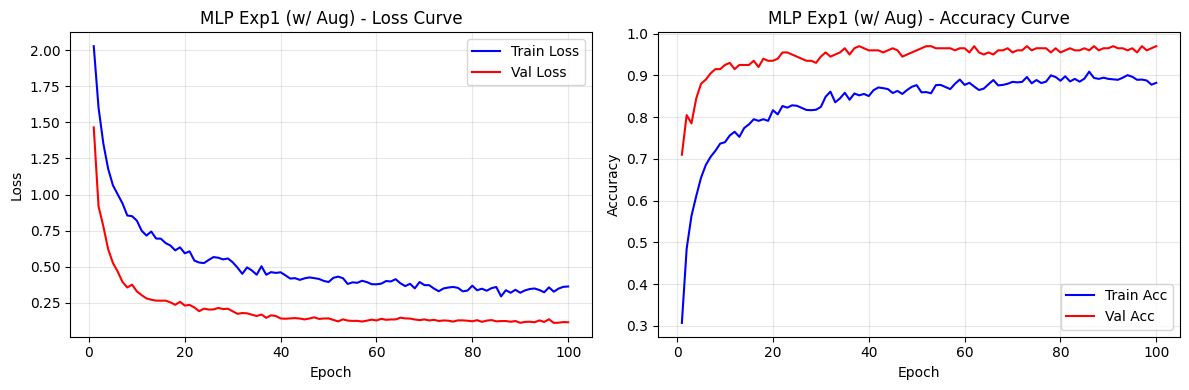

Saved: result/14_mlp_aug_exp1_history.png

--- Experiment 2 ---
  Training MLP_Aug_exp2 | epochs=100, batch=64, lr=0.001
  Train: 1800, Validation: 200, Test: 2000
  Epoch   1/100 | train_loss=2.0521 acc=0.2917 | val_loss=1.5579 acc=0.6750 | lr=1.00e-03
  Epoch  10/100 | train_loss=0.7766 acc=0.7428 | val_loss=0.3019 acc=0.9050 | lr=1.00e-03
  Epoch  20/100 | train_loss=0.5750 acc=0.8083 | val_loss=0.1691 acc=0.9650 | lr=1.00e-03
  Epoch  30/100 | train_loss=0.5621 acc=0.8206 | val_loss=0.1498 acc=0.9650 | lr=1.00e-03
  Epoch  40/100 | train_loss=0.4690 acc=0.8489 | val_loss=0.1234 acc=0.9650 | lr=1.00e-03
  Epoch  50/100 | train_loss=0.4040 acc=0.8606 | val_loss=0.1191 acc=0.9650 | lr=5.00e-04
  Epoch  60/100 | train_loss=0.3710 acc=0.8833 | val_loss=0.0934 acc=0.9800 | lr=2.50e-04
  Epoch  70/100 | train_loss=0.3532 acc=0.8839 | val_loss=0.0998 acc=0.9700 | lr=1.25e-04
  Epoch  80/100 | train_loss=0.3322 acc=0.8956 | val_loss=0.0887 acc=0.9700 | lr=6.25e-05
  Epoch  90/100 | train_lo

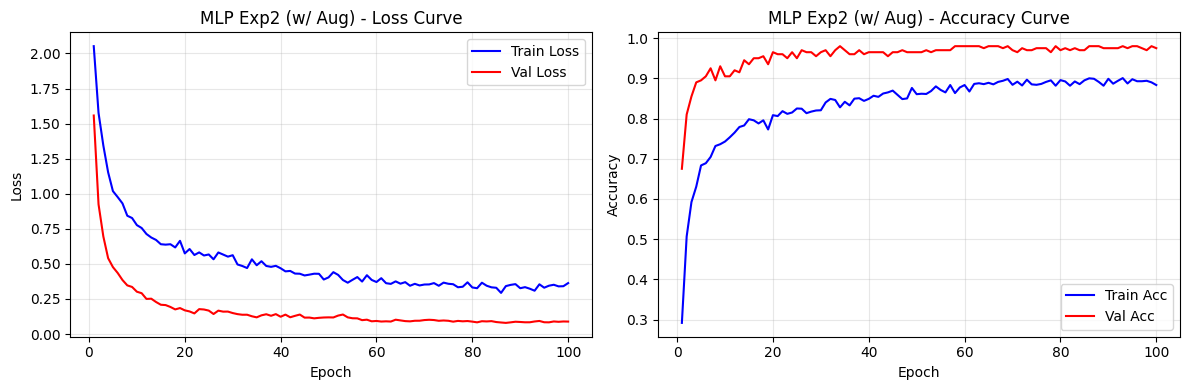

Saved: result/14_mlp_aug_exp2_history.png

MLP (w/ aug) mean accuracy: 0.9685 ± 0.0005


In [11]:
print('=' * 60)
print('  MLP (3 hidden layers + Data Augmentation)')
print('=' * 60)

mlp_aug_accs = []

for exp in [1, 2]:
    print(f'\n--- Experiment {exp} ---')
    tr_idx = exp_idx[exp]['train']
    te_idx = exp_idx[exp]['test']
    
    model_aug, hist_aug, test_acc, y_pred, y_true = train_model(
        MLP,
        {'hidden_dims': [512, 256, 128], 'dropout_rate': 0.4},
        X_norm[tr_idx], y_all[tr_idx],
        X_norm[te_idx], y_all[te_idx],
        augment=True,  # Enable data augmentation
        epochs=100,
        batch_size=64,
        lr=1e-3,
        weight_decay=1e-4,
        patience=20,
        model_name=f'MLP_Aug_exp{exp}'
    )
    mlp_aug_accs.append(test_acc)
    plot_training_history(hist_aug, f'MLP Exp{exp} (w/ Aug)',
                           f'result/14_mlp_aug_exp{exp}_history.png')

dl_results['MLP (3-layer, w/ aug)'] = {
    'exp1': mlp_aug_accs[0], 'exp2': mlp_aug_accs[1],
    'mean': np.mean(mlp_aug_accs), 'std': np.std(mlp_aug_accs)
}
print(f'\nMLP (w/ aug) mean accuracy: {np.mean(mlp_aug_accs):.4f} ± {np.std(mlp_aug_accs):.4f}')

## 7. MLP Network Depth Comparison Experiment

  MLP Network Depth Comparison (1/2/3 Hidden Layers)
  Training MLP_1-layer(512)_exp1 | epochs=60, batch=64, lr=0.001
  Train: 1800, Validation: 200, Test: 2000
  Epoch   1/60 | train_loss=0.8544 acc=0.7522 | val_loss=0.5619 acc=0.8750 | lr=1.00e-03
  Epoch  10/60 | train_loss=0.0495 acc=0.9972 | val_loss=0.3549 acc=0.9000 | lr=1.00e-03
  Epoch  20/60 | train_loss=0.0242 acc=0.9978 | val_loss=0.4034 acc=0.8950 | lr=2.50e-04
  EarlyStopping at epoch 20
  Test Accuracy: 0.9155 | Total Time: 2.3s
  Training MLP_1-layer(512)_exp2 | epochs=60, batch=64, lr=0.001
  Train: 1800, Validation: 200, Test: 2000
  Epoch   1/60 | train_loss=0.8386 acc=0.7528 | val_loss=0.4809 acc=0.9150 | lr=1.00e-03
  Epoch  10/60 | train_loss=0.0472 acc=0.9944 | val_loss=0.2794 acc=0.9350 | lr=1.00e-03
  Epoch  20/60 | train_loss=0.0395 acc=0.9939 | val_loss=0.2835 acc=0.9300 | lr=1.00e-03
  Epoch  30/60 | train_loss=0.0252 acc=0.9950 | val_loss=0.3117 acc=0.9250 | lr=5.00e-04
  EarlyStopping at epoch 33
  Test Ac

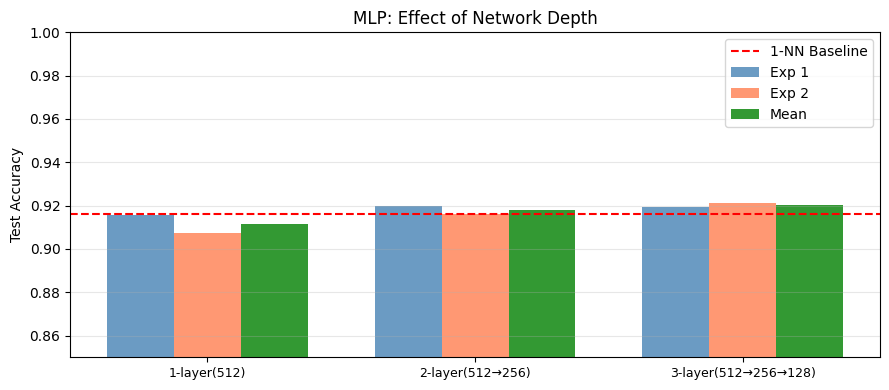

Saved: result/15_mlp_depth_comparison.png


In [12]:
print('=' * 60)
print('  MLP Network Depth Comparison (1/2/3 Hidden Layers)')
print('=' * 60)

depth_configs = {
    '1-layer(512)':     [512],
    '2-layer(512→256)': [512, 256],
    '3-layer(512→256→128)': [512, 256, 128]
}

depth_accs = {}
for config_name, hidden_dims in depth_configs.items():
    accs = []
    for exp in [1, 2]:
        tr_idx = exp_idx[exp]['train']
        te_idx = exp_idx[exp]['test']
        _, _, test_acc, _, _ = train_model(
            MLP,
            {'hidden_dims': hidden_dims, 'dropout_rate': 0.4},
            X_norm[tr_idx], y_all[tr_idx],
            X_norm[te_idx], y_all[te_idx],
            augment=False, epochs=60, batch_size=64,
            lr=1e-3, patience=12,
            model_name=f'MLP_{config_name}_exp{exp}'
        )
        accs.append(test_acc)
    depth_accs[config_name] = {'exp1': accs[0], 'exp2': accs[1], 'mean': np.mean(accs)}
    print(f'  {config_name}: Exp 1={accs[0]:.4f}, Exp 2={accs[1]:.4f}, Mean={np.mean(accs):.4f}')

# Visualize depth comparison
fig, ax = plt.subplots(figsize=(9, 4))
names = list(depth_configs.keys())
e1s = [depth_accs[n]['exp1'] for n in names]
e2s = [depth_accs[n]['exp2'] for n in names]
means = [depth_accs[n]['mean'] for n in names]
x = np.arange(len(names))
ax.bar(x - 0.25, e1s, 0.25, label='Exp 1', color='steelblue', alpha=0.8)
ax.bar(x, e2s, 0.25, label='Exp 2', color='coral', alpha=0.8)
ax.bar(x + 0.25, means, 0.25, label='Mean', color='green', alpha=0.8)
ax.axhline(y=0.9160, color='red', linestyle='--', label='1-NN Baseline')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel('Test Accuracy')
ax.set_title('MLP: Effect of Network Depth')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0.85, 1.0)
plt.tight_layout()
plt.savefig('result/15_mlp_depth_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: result/15_mlp_depth_comparison.png')

## 8. CNN Training (Without Data Augmentation)

  CNN (LeNet-5 Style, No Data Augmentation)
  Input: 784D -> Reshape to 28x28 -> Conv2D -> MaxPool -> ...

--- Experiment 1 ---
  Training CNN_exp1 | epochs=80, batch=64, lr=0.001
  Train: 1800, Validation: 200, Test: 2000
  Epoch   1/80 | train_loss=1.8916 acc=0.3917 | val_loss=1.4880 acc=0.6250 | lr=1.00e-03
  Epoch  10/80 | train_loss=0.1216 acc=0.9606 | val_loss=0.1605 acc=0.9550 | lr=1.00e-03
  Epoch  20/80 | train_loss=0.0443 acc=0.9856 | val_loss=0.1353 acc=0.9550 | lr=1.00e-03
  Epoch  30/80 | train_loss=0.0257 acc=0.9939 | val_loss=0.1732 acc=0.9500 | lr=1.00e-03
  Epoch  40/80 | train_loss=0.0107 acc=0.9983 | val_loss=0.1753 acc=0.9650 | lr=5.00e-04
  EarlyStopping at epoch 47
  Test Accuracy: 0.9590 | Total Time: 7.2s


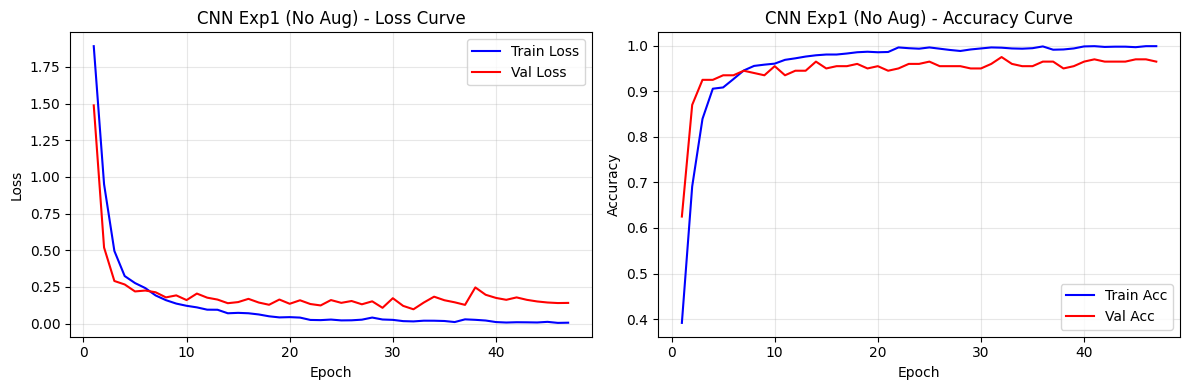

Saved: result/16_cnn_exp1_history.png

--- Experiment 2 ---
  Training CNN_exp2 | epochs=80, batch=64, lr=0.001
  Train: 1800, Validation: 200, Test: 2000
  Epoch   1/80 | train_loss=1.8967 acc=0.3961 | val_loss=1.4673 acc=0.5950 | lr=1.00e-03
  Epoch  10/80 | train_loss=0.1120 acc=0.9644 | val_loss=0.1149 acc=0.9700 | lr=1.00e-03
  Epoch  20/80 | train_loss=0.0255 acc=0.9933 | val_loss=0.1065 acc=0.9700 | lr=5.00e-04
  Epoch  30/80 | train_loss=0.0153 acc=0.9978 | val_loss=0.0945 acc=0.9750 | lr=2.50e-04
  EarlyStopping at epoch 34
  Test Accuracy: 0.9610 | Total Time: 4.6s


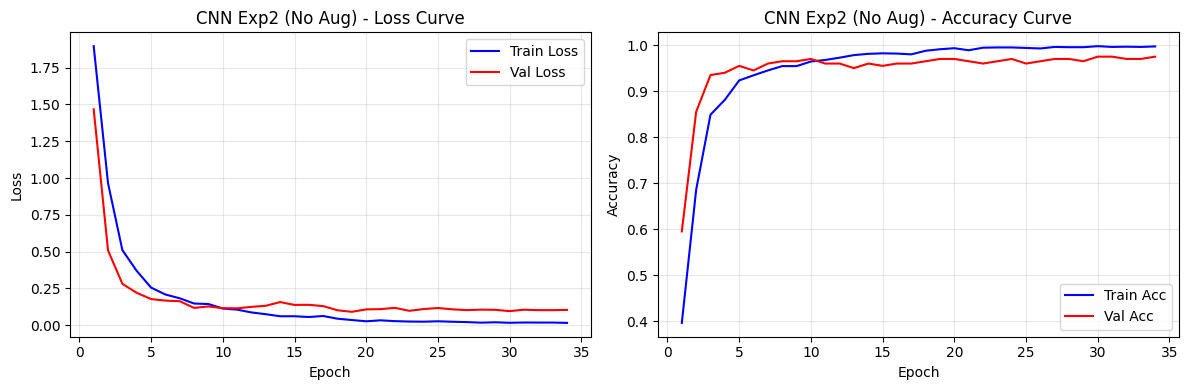

Saved: result/16_cnn_exp2_history.png

CNN (no aug) mean accuracy: 0.9600 ± 0.0010


In [13]:
print('=' * 60)
print('  CNN (LeNet-5 Style, No Data Augmentation)')
print('  Input: 784D -> Reshape to 28x28 -> Conv2D -> MaxPool -> ...')
print('=' * 60)

cnn_accs = []

for exp in [1, 2]:
    print(f'\n--- Experiment {exp} ---')
    tr_idx = exp_idx[exp]['train']
    te_idx = exp_idx[exp]['test']
    
    model_cnn, hist_cnn, test_acc, y_pred, y_true = train_model(
        CNN,
        {'dropout_rate': 0.3},
        X_norm[tr_idx], y_all[tr_idx],
        X_norm[te_idx], y_all[te_idx],
        augment=False,
        epochs=80,
        batch_size=64,
        lr=1e-3,
        weight_decay=1e-4,
        patience=15,
        model_name=f'CNN_exp{exp}'
    )
    cnn_accs.append(test_acc)
    plot_training_history(hist_cnn, f'CNN Exp{exp} (No Aug)',
                           f'result/16_cnn_exp{exp}_history.png')

dl_results['CNN (LeNet-5, no aug)'] = {
    'exp1': cnn_accs[0], 'exp2': cnn_accs[1],
    'mean': np.mean(cnn_accs), 'std': np.std(cnn_accs)
}
print(f'\nCNN (no aug) mean accuracy: {np.mean(cnn_accs):.4f} ± {np.std(cnn_accs):.4f}')

## 9. CNN Training (With Data Augmentation)

  CNN (LeNet-5 Style + Data Augmentation)

--- Experiment 1 ---
  Training CNN_Aug_exp1 | epochs=100, batch=64, lr=0.001
  Train: 1800, Validation: 200, Test: 2000
  Epoch   1/100 | train_loss=2.1360 acc=0.2583 | val_loss=1.8520 acc=0.4500 | lr=1.00e-03
  Epoch  10/100 | train_loss=0.4269 acc=0.8739 | val_loss=0.1611 acc=0.9550 | lr=1.00e-03
  Epoch  20/100 | train_loss=0.2631 acc=0.9217 | val_loss=0.1124 acc=0.9650 | lr=1.00e-03
  Epoch  30/100 | train_loss=0.1752 acc=0.9433 | val_loss=0.0822 acc=0.9600 | lr=1.00e-03
  Epoch  40/100 | train_loss=0.1649 acc=0.9472 | val_loss=0.0681 acc=0.9750 | lr=5.00e-04
  Epoch  50/100 | train_loss=0.1315 acc=0.9600 | val_loss=0.0639 acc=0.9750 | lr=2.50e-04
  Epoch  60/100 | train_loss=0.1155 acc=0.9656 | val_loss=0.0665 acc=0.9750 | lr=1.25e-04
  Epoch  70/100 | train_loss=0.1030 acc=0.9700 | val_loss=0.0583 acc=0.9800 | lr=6.25e-05
  Epoch  80/100 | train_loss=0.1083 acc=0.9700 | val_loss=0.0621 acc=0.9800 | lr=1.56e-05
  Epoch  90/100 | train_lo

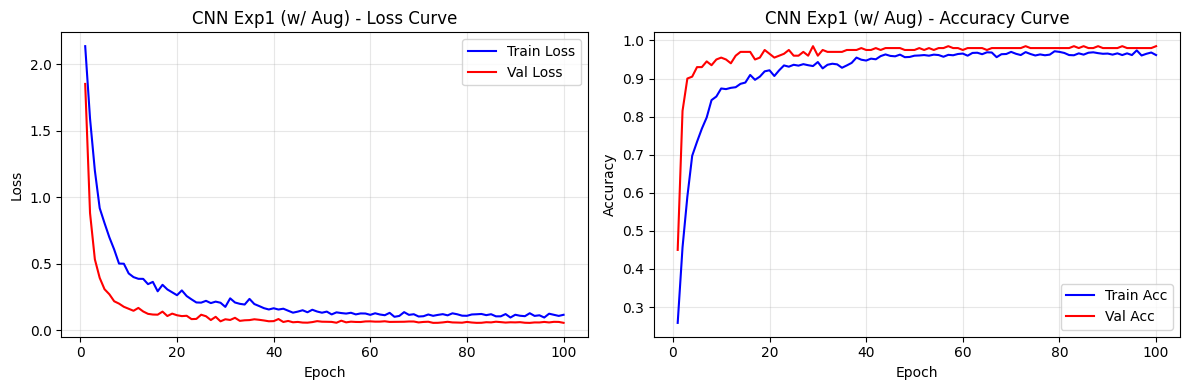

Saved: result/17_cnn_aug_exp1_history.png

--- Experiment 2 ---
  Training CNN_Aug_exp2 | epochs=100, batch=64, lr=0.001
  Train: 1800, Validation: 200, Test: 2000
  Epoch   1/100 | train_loss=2.1450 acc=0.2422 | val_loss=1.8252 acc=0.4600 | lr=1.00e-03
  Epoch  10/100 | train_loss=0.4506 acc=0.8517 | val_loss=0.1162 acc=0.9750 | lr=1.00e-03
  Epoch  20/100 | train_loss=0.2619 acc=0.9122 | val_loss=0.0906 acc=0.9750 | lr=1.00e-03
  Epoch  30/100 | train_loss=0.2275 acc=0.9289 | val_loss=0.0383 acc=0.9850 | lr=1.00e-03
  Epoch  40/100 | train_loss=0.1528 acc=0.9533 | val_loss=0.0300 acc=0.9900 | lr=5.00e-04
  Epoch  50/100 | train_loss=0.1637 acc=0.9450 | val_loss=0.0340 acc=0.9900 | lr=5.00e-04
  Epoch  60/100 | train_loss=0.1273 acc=0.9600 | val_loss=0.0137 acc=0.9950 | lr=2.50e-04
  Epoch  70/100 | train_loss=0.1307 acc=0.9644 | val_loss=0.0140 acc=0.9950 | lr=2.50e-04
  Epoch  80/100 | train_loss=0.0996 acc=0.9639 | val_loss=0.0160 acc=0.9950 | lr=6.25e-05
  EarlyStopping at epoch 8

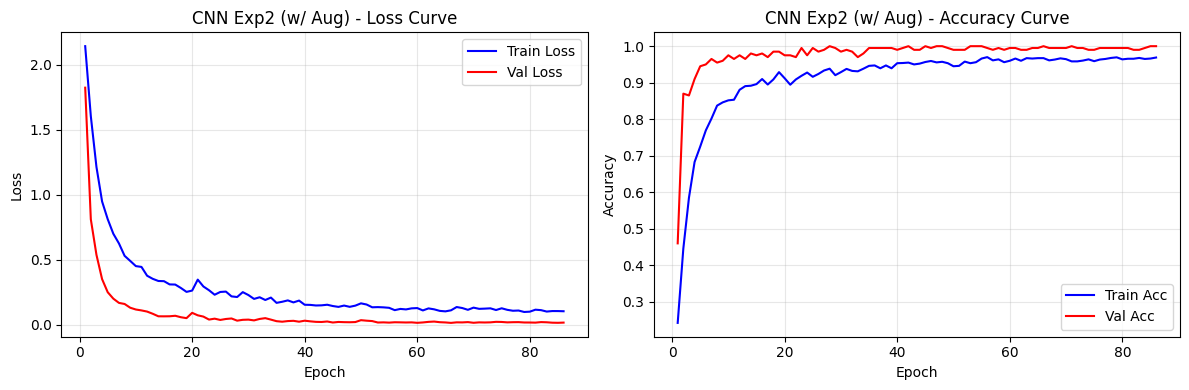

Saved: result/17_cnn_aug_exp2_history.png

CNN (w/ aug) mean accuracy: 0.9808 ± 0.0018


In [14]:
print('=' * 60)
print('  CNN (LeNet-5 Style + Data Augmentation)')
print('=' * 60)

cnn_aug_accs = []
cnn_aug_preds = []

for exp in [1, 2]:
    print(f'\n--- Experiment {exp} ---')
    tr_idx = exp_idx[exp]['train']
    te_idx = exp_idx[exp]['test']
    
    model_cnn_aug, hist_cnn_aug, test_acc, y_pred, y_true = train_model(
        CNN,
        {'dropout_rate': 0.3},
        X_norm[tr_idx], y_all[tr_idx],
        X_norm[te_idx], y_all[te_idx],
        augment=True,  # Enable data augmentation
        epochs=100,
        batch_size=64,
        lr=1e-3,
        weight_decay=1e-4,
        patience=20,
        model_name=f'CNN_Aug_exp{exp}'
    )
    cnn_aug_accs.append(test_acc)
    cnn_aug_preds.append((y_pred, y_true))
    plot_training_history(hist_cnn_aug, f'CNN Exp{exp} (w/ Aug)',
                           f'result/17_cnn_aug_exp{exp}_history.png')

dl_results['CNN (LeNet-5, w/ aug)'] = {
    'exp1': cnn_aug_accs[0], 'exp2': cnn_aug_accs[1],
    'mean': np.mean(cnn_aug_accs), 'std': np.std(cnn_aug_accs)
}
print(f'\nCNN (w/ aug) mean accuracy: {np.mean(cnn_aug_accs):.4f} ± {np.std(cnn_aug_accs):.4f}')

## 10. CNN Dropout Parameter Comparison Experiment

  CNN Dropout Rate Comparison
  Training CNN_dr0.0_exp1 | epochs=60, batch=64, lr=0.001
  Train: 1800, Validation: 200, Test: 2000
  Epoch   1/60 | train_loss=1.6196 acc=0.5750 | val_loss=1.2211 acc=0.6950 | lr=1.00e-03
  Epoch  10/60 | train_loss=0.0336 acc=0.9939 | val_loss=0.1664 acc=0.9400 | lr=1.00e-03
  Epoch  20/60 | train_loss=0.0037 acc=1.0000 | val_loss=0.1443 acc=0.9550 | lr=1.00e-03
  Epoch  30/60 | train_loss=0.0013 acc=1.0000 | val_loss=0.1521 acc=0.9600 | lr=5.00e-04
  EarlyStopping at epoch 35
  Test Accuracy: 0.9605 | Total Time: 3.2s
  Training CNN_dr0.0_exp2 | epochs=60, batch=64, lr=0.001
  Train: 1800, Validation: 200, Test: 2000
  Epoch   1/60 | train_loss=1.6385 acc=0.5611 | val_loss=1.1260 acc=0.7350 | lr=1.00e-03
  Epoch  10/60 | train_loss=0.0408 acc=0.9883 | val_loss=0.1182 acc=0.9700 | lr=1.00e-03
  Epoch  20/60 | train_loss=0.0044 acc=1.0000 | val_loss=0.0992 acc=0.9750 | lr=5.00e-04
  EarlyStopping at epoch 27
  Test Accuracy: 0.9585 | Total Time: 2.3s
  D

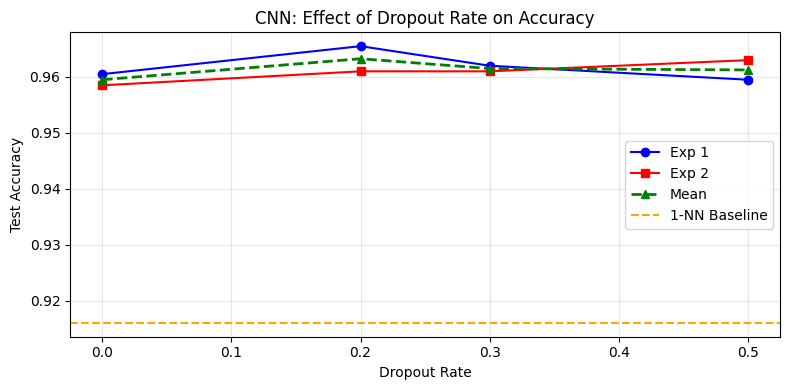

Saved: result/18_cnn_dropout_analysis.png


In [15]:
print('=' * 60)
print('  CNN Dropout Rate Comparison')
print('=' * 60)

dropout_vals = [0.0, 0.2, 0.3, 0.5]
dropout_accs = {}

for dr in dropout_vals:
    accs = []
    for exp in [1, 2]:
        tr_idx = exp_idx[exp]['train']
        te_idx = exp_idx[exp]['test']
        _, _, test_acc, _, _ = train_model(
            CNN, {'dropout_rate': dr},
            X_norm[tr_idx], y_all[tr_idx],
            X_norm[te_idx], y_all[te_idx],
            augment=False, epochs=60, batch_size=64, lr=1e-3, patience=12,
            model_name=f'CNN_dr{dr}_exp{exp}'
        )
        accs.append(test_acc)
    dropout_accs[dr] = {'exp1': accs[0], 'exp2': accs[1], 'mean': np.mean(accs)}
    print(f'  Dropout={dr}: Exp 1={accs[0]:.4f}, Exp 2={accs[1]:.4f}, Mean={np.mean(accs):.4f}')

# Dropout comparison chart
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dropout_vals, [dropout_accs[d]['exp1'] for d in dropout_vals], 'b-o', label='Exp 1')
ax.plot(dropout_vals, [dropout_accs[d]['exp2'] for d in dropout_vals], 'r-s', label='Exp 2')
ax.plot(dropout_vals, [dropout_accs[d]['mean'] for d in dropout_vals], 'g--^', label='Mean', lw=2)
ax.axhline(y=0.9160, color='orange', linestyle='--', label='1-NN Baseline')
ax.set_xlabel('Dropout Rate')
ax.set_ylabel('Test Accuracy')
ax.set_title('CNN: Effect of Dropout Rate on Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('result/18_cnn_dropout_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: result/18_cnn_dropout_analysis.png')

## 11. CNN Confusion Matrix Analysis

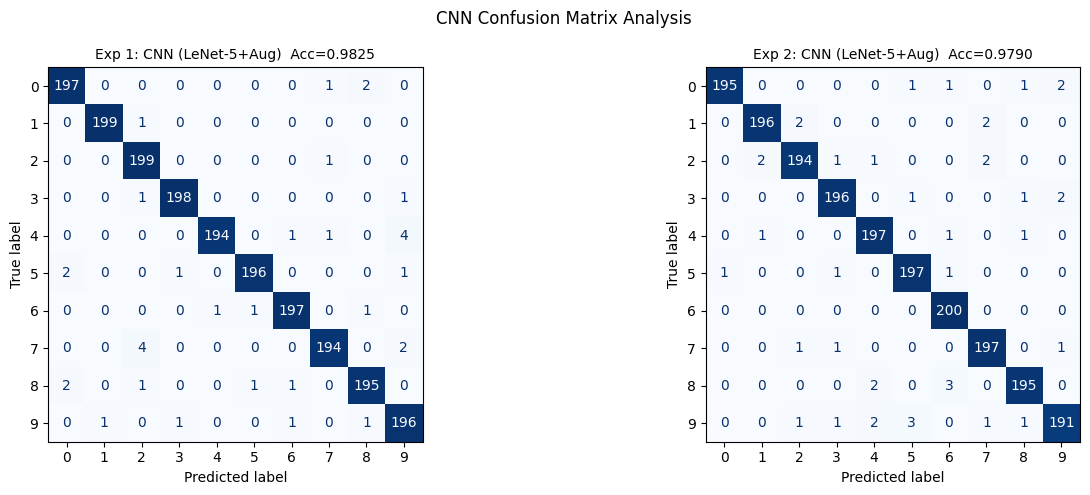

Saved: result/19_cnn_confusion_matrix.png


In [16]:
# Confusion matrix of the best CNN (with augmentation)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp_i, (y_pred, y_true) in zip(axes, [1, 2], cnn_aug_preds):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f'Exp {exp_i}: CNN (LeNet-5+Aug)  Acc={acc:.4f}', fontsize=10)

plt.suptitle('CNN Confusion Matrix Analysis', fontsize=12)
plt.tight_layout()
plt.savefig('result/19_cnn_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: result/19_cnn_confusion_matrix.png')

## 12. Analysis of Typical Success and Failure Cases

Experiment 1 - CNN (w/ Aug) Error count: 35 / 2000


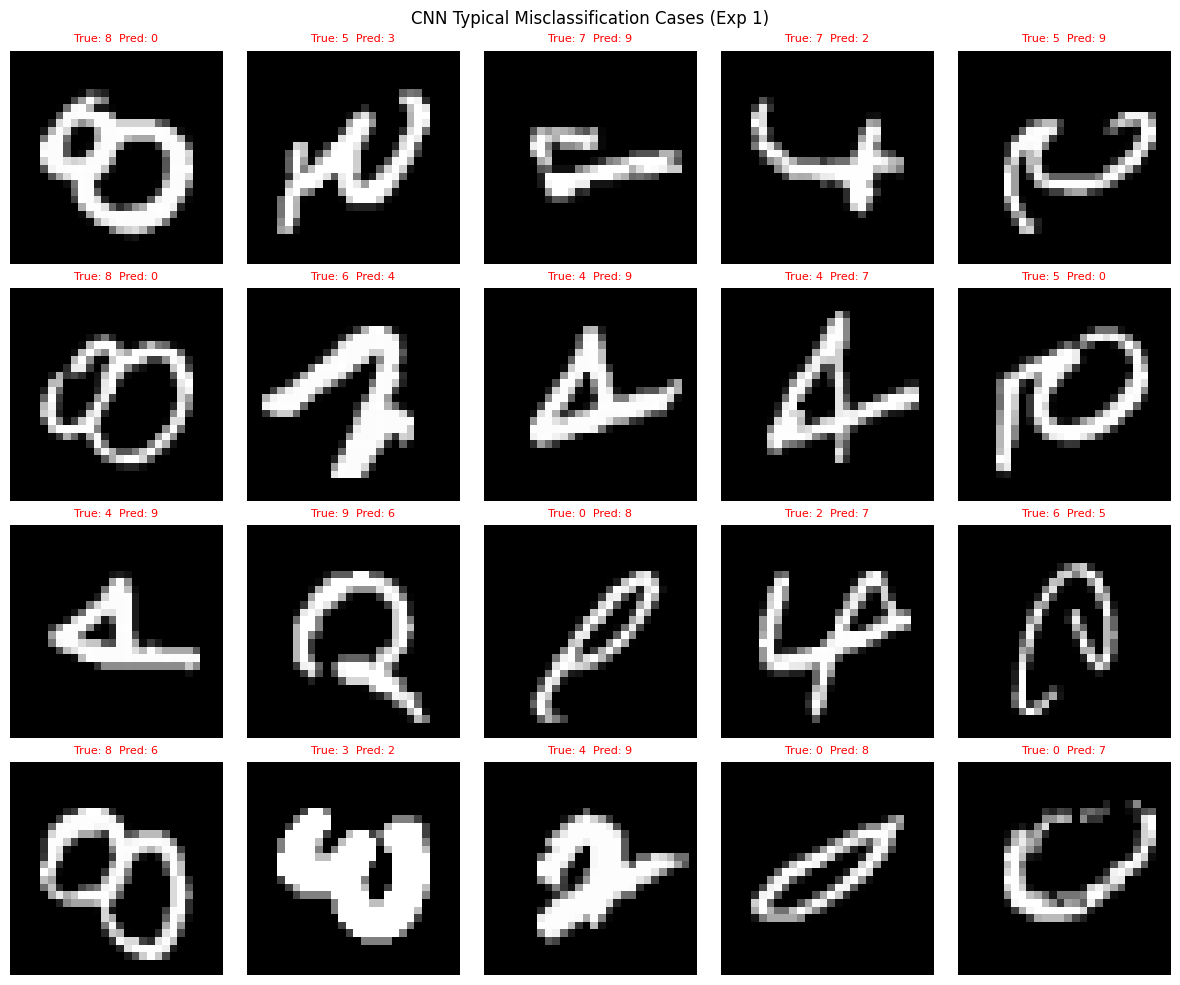

Saved: result/20_cnn_error_analysis.png

Most common confusion pairs (True -> Pred):
  Digit 4 -> Digit 9: 4 times
  Digit 7 -> Digit 2: 4 times
  Digit 0 -> Digit 8: 2 times
  Digit 5 -> Digit 0: 2 times
  Digit 7 -> Digit 9: 2 times
  Digit 8 -> Digit 0: 2 times
  Digit 0 -> Digit 7: 1 times
  Digit 1 -> Digit 2: 1 times
  Digit 2 -> Digit 7: 1 times
  Digit 3 -> Digit 2: 1 times


In [17]:
# Analyze typical error cases in Experiment 1
y_pred_exp1, y_true_exp1 = cnn_aug_preds[0]
te_idx_exp1 = exp_idx[1]['test']
X_test_exp1 = X_norm[te_idx_exp1]

wrong_mask = y_pred_exp1 != y_true_exp1
wrong_indices = np.where(wrong_mask)[0]

print(f'Experiment 1 - CNN (w/ Aug) Error count: {len(wrong_indices)} / {len(y_true_exp1)}')

# Show up to 20 error samples
n_show = min(20, len(wrong_indices))
np.random.seed(42)
show_idx = np.random.choice(wrong_indices, n_show, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for i, (ax, idx) in enumerate(zip(axes.flatten(), show_idx)):
    img = X_test_exp1[idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    true_label = y_true_exp1[idx]
    pred_label = y_pred_exp1[idx]
    ax.set_title(f'True: {true_label}  Pred: {pred_label}',
                 color='red', fontsize=8)
    ax.axis('off')

plt.suptitle('CNN Typical Misclassification Cases (Exp 1)', fontsize=12)
plt.tight_layout()
plt.savefig('result/20_cnn_error_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: result/20_cnn_error_analysis.png')

# Most frequent misclassification pairs
from collections import Counter
error_pairs = Counter(zip(y_true_exp1[wrong_mask], y_pred_exp1[wrong_mask]))
print('\nMost common confusion pairs (True -> Pred):')
for (true, pred), count in error_pairs.most_common(10):
    print(f'  Digit {true} -> Digit {pred}: {count} times')

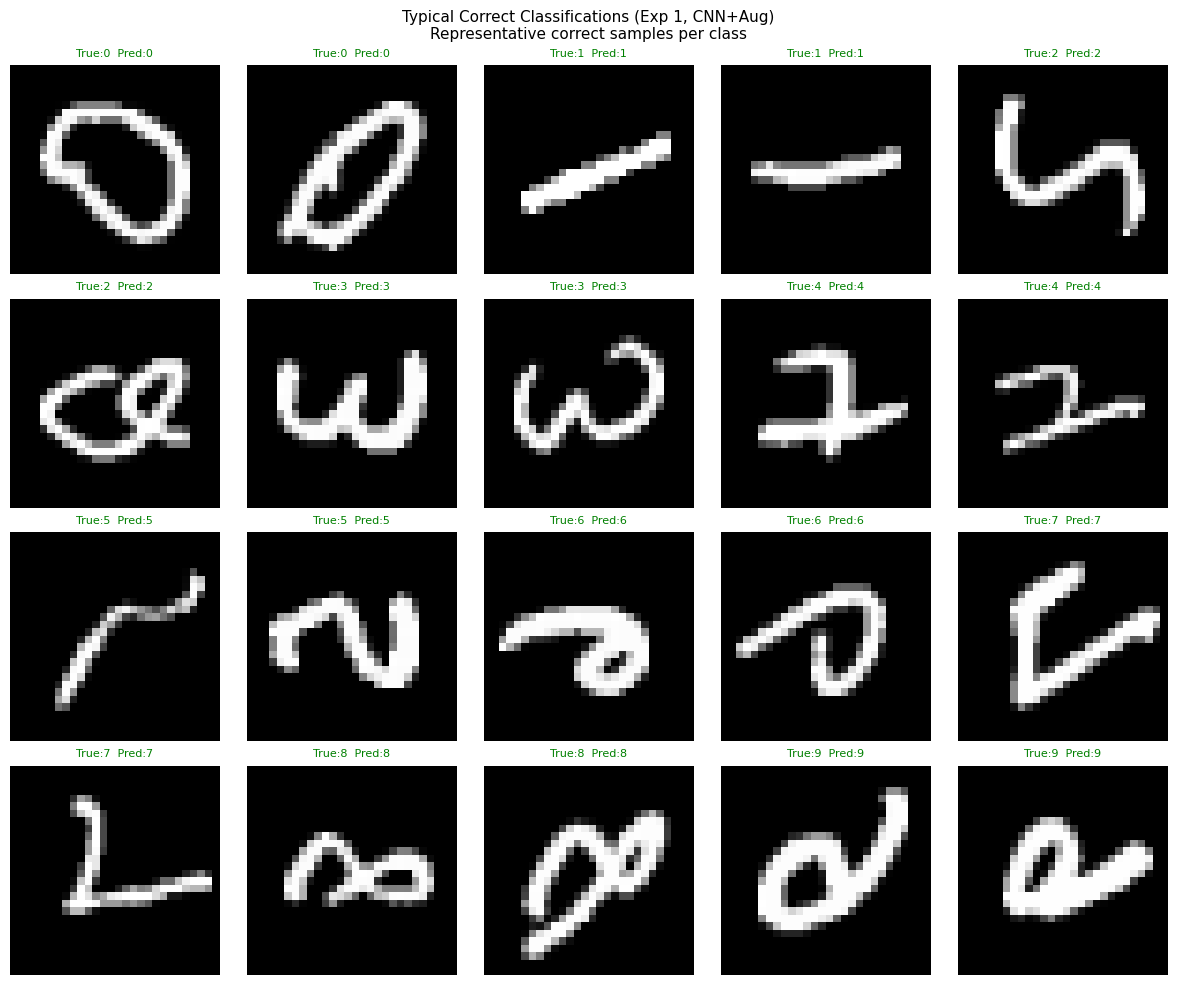

Saved: result/19_success_cases.png
Displayed 20 typical success cases


In [18]:
# ---- Typical Success Cases Analysis (Exp 1) ----
y_pred_exp1, y_true_exp1 = cnn_aug_preds[0]
te_idx1 = exp_idx[1]['test']
X_test1 = X_norm[te_idx1]

correct_mask = (y_pred_exp1 == y_true_exp1)

# Select correct samples with the highest confidence for each class (max 2)
success_samples = []
for digit in range(10):
    cls_mask = correct_mask & (y_true_exp1 == digit)
    idxs = np.where(cls_mask)[0]
    if len(idxs) > 0:
        for si in idxs[:2]:
            success_samples.append((si, y_true_exp1[si], y_pred_exp1[si]))
        if len(success_samples) >= 20:
            break

n_success = min(20, len(success_samples))
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
axes = axes.ravel()
for k, (si, true_lbl, pred_lbl) in enumerate(success_samples[:n_success]):
    img = X_test1[si].reshape(28, 28)
    axes[k].imshow(img, cmap='gray')
    axes[k].set_title(f'True:{true_lbl}  Pred:{pred_lbl}', color='green', fontsize=8)
    axes[k].axis('off')
for k in range(n_success, len(axes)):
    axes[k].axis('off')

plt.suptitle('Typical Correct Classifications (Exp 1, CNN+Aug)\nRepresentative correct samples per class',
             fontsize=11)
plt.tight_layout()
plt.savefig('result/19_success_cases.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: result/19_success_cases.png')
print(f'Displayed {n_success} typical success cases')

## 13. Comprehensive Comparison of All Deep Learning Methods

In [19]:
print('\n' + '=' * 70)
print('        Summary of Deep Learning Methods Accuracy')
print('=' * 70)
print(f'{"Method":<30} {"Exp 1":>8} {"Exp 2":>8} {"Mean":>8} {"Std":>8}')
print('-' * 70)
print(f'{"1-NN Baseline (Official)":<30} {0.9135:>8.4f} {0.9185:>8.4f} {0.9160:>8.4f} {0.0035:>8.4f}')
for name, r in dl_results.items():
    marker = ' *' if r['mean'] > 0.9160 else '  '
    print(f'{name:<30} {r["exp1"]:>8.4f} {r["exp2"]:>8.4f} {r["mean"]:>8.4f} {r["std"]:>8.4f}{marker}')
print('=' * 70)
print('Note: * indicates performance above 1-NN Baseline (0.9160)')


        Summary of Deep Learning Methods Accuracy
Method                            Exp 1    Exp 2     Mean      Std
----------------------------------------------------------------------
1-NN Baseline (Official)         0.9135   0.9185   0.9160   0.0035
MLP (3-layer, no aug)            0.9195   0.9210   0.9203   0.0008 *
MLP (3-layer, w/ aug)            0.9690   0.9680   0.9685   0.0005 *
CNN (LeNet-5, no aug)            0.9590   0.9610   0.9600   0.0010 *
CNN (LeNet-5, w/ aug)            0.9825   0.9790   0.9808   0.0018 *
Note: * indicates performance above 1-NN Baseline (0.9160)


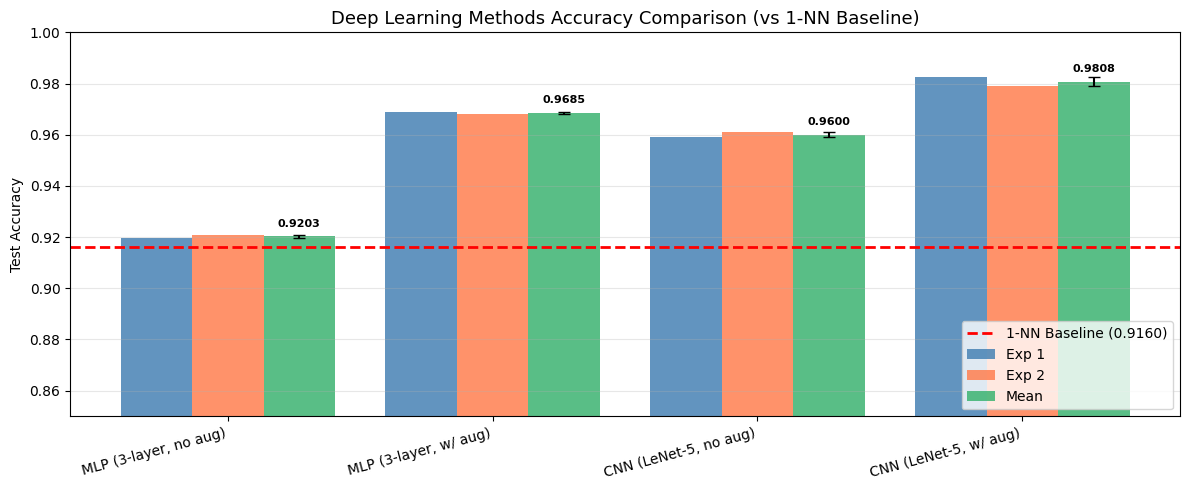

Saved: result/21_dl_methods_comparison.png


In [20]:
# Comprehensive comparison chart for deep learning methods
method_names = list(dl_results.keys())
exp1_accs = [dl_results[m]['exp1'] for m in method_names]
exp2_accs = [dl_results[m]['exp2'] for m in method_names]
mean_accs = [dl_results[m]['mean'] for m in method_names]
std_accs  = [dl_results[m]['std']  for m in method_names]

x = np.arange(len(method_names))
width = 0.27

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - width, exp1_accs, width, label='Exp 1', color='steelblue', alpha=0.85)
b2 = ax.bar(x, exp2_accs, width, label='Exp 2', color='coral', alpha=0.85)
b3 = ax.bar(x + width, mean_accs, width, label='Mean', color='mediumseagreen', alpha=0.85,
            yerr=std_accs, capsize=4, error_kw={'elinewidth': 1.5})

ax.axhline(y=0.9160, color='red', linestyle='--', linewidth=2, label='1-NN Baseline (0.9160)')

ax.set_xticks(x)
ax.set_xticklabels(method_names, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Test Accuracy')
ax.set_title('Deep Learning Methods Accuracy Comparison (vs 1-NN Baseline)', fontsize=13)
ax.legend(loc='lower right')
ax.set_ylim(0.85, 1.0)
ax.grid(True, axis='y', alpha=0.3)

# Annotate mean values
for bar, mean in zip(b3, mean_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('result/21_dl_methods_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: result/21_dl_methods_comparison.png')

## 14. Data Augmentation Effect Comparison (MLP vs CNN)

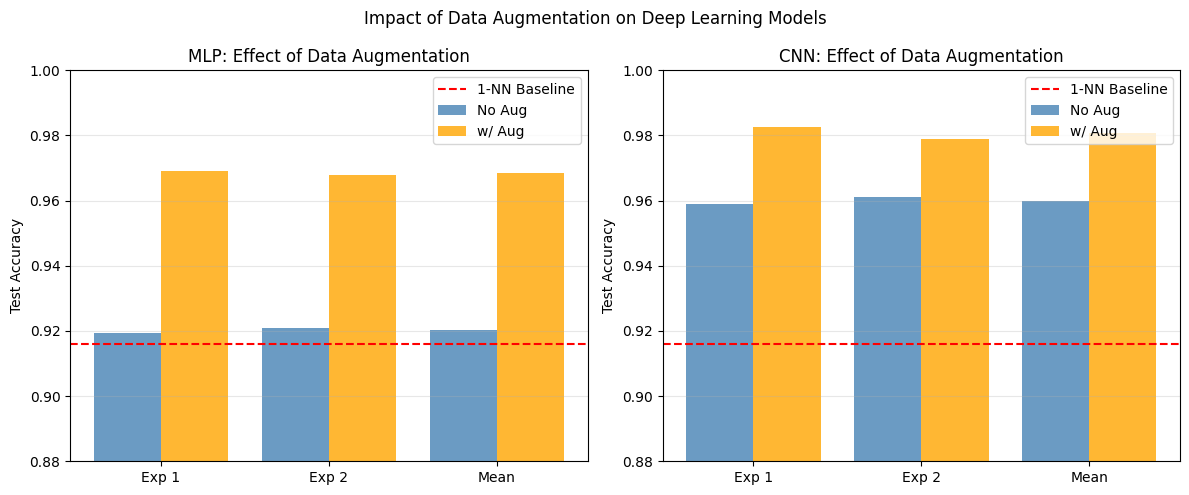

Saved: result/22_augmentation_effect_comparison.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MLP: No Aug vs w/ Aug
ax = axes[0]
categories = ['Exp 1', 'Exp 2', 'Mean']
no_aug = [dl_results['MLP (3-layer, no aug)']['exp1'],
           dl_results['MLP (3-layer, no aug)']['exp2'],
           dl_results['MLP (3-layer, no aug)']['mean']]
with_aug = [dl_results['MLP (3-layer, w/ aug)']['exp1'],
             dl_results['MLP (3-layer, w/ aug)']['exp2'],
             dl_results['MLP (3-layer, w/ aug)']['mean']]
x = np.arange(3)
ax.bar(x - 0.2, no_aug, 0.4, label='No Aug', color='steelblue', alpha=0.8)
ax.bar(x + 0.2, with_aug, 0.4, label='w/ Aug', color='orange', alpha=0.8)
ax.axhline(y=0.9160, color='red', linestyle='--', label='1-NN Baseline')
ax.set_title('MLP: Effect of Data Augmentation')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Test Accuracy')
ax.legend()
ax.set_ylim(0.88, 1.0)
ax.grid(True, axis='y', alpha=0.3)

# CNN: No Aug vs w/ Aug
ax = axes[1]
no_aug_cnn = [dl_results['CNN (LeNet-5, no aug)']['exp1'],
               dl_results['CNN (LeNet-5, no aug)']['exp2'],
               dl_results['CNN (LeNet-5, no aug)']['mean']]
with_aug_cnn = [dl_results['CNN (LeNet-5, w/ aug)']['exp1'],
                 dl_results['CNN (LeNet-5, w/ aug)']['exp2'],
                 dl_results['CNN (LeNet-5, w/ aug)']['mean']]
ax.bar(x - 0.2, no_aug_cnn, 0.4, label='No Aug', color='steelblue', alpha=0.8)
ax.bar(x + 0.2, with_aug_cnn, 0.4, label='w/ Aug', color='orange', alpha=0.8)
ax.axhline(y=0.9160, color='red', linestyle='--', label='1-NN Baseline')
ax.set_title('CNN: Effect of Data Augmentation')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Test Accuracy')
ax.legend()
ax.set_ylim(0.88, 1.0)
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Impact of Data Augmentation on Deep Learning Models', fontsize=12)
plt.tight_layout()
plt.savefig('result/22_augmentation_effect_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: result/22_augmentation_effect_comparison.png')